In [9]:
import sys
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Layer
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Add path for data loader
sys.path.append(os.path.abspath('..'))
from src.data_loader import SP500DataLoader

print("✅ All imports ready")

✅ All imports ready


In [24]:
print("="*60)
print("STEP 1: LOAD TRAINING DATA FROM YOUR CACHE")
print("="*60)

loader = SP500DataLoader(start_year=1997, end_year=2024)
df = loader.load_all()

# Extract log returns
all_returns = df['log_returns'].dropna()

# Use pre-COVID period for training (2010-2019)
train_returns = all_returns['2010':'2019'].values

print(f"Training data shape: {train_returns.shape}")
print(f"Date range: 2010-01-01 to 2019-12-31")
print(f"Mean: {train_returns.mean():.8f}")
print(f"Std: {train_returns.std():.8f}")

STEP 1: LOAD TRAINING DATA FROM YOUR CACHE
Training data shape: (2516,)
Date range: 2010-01-01 to 2019-12-31
Mean: 0.00042281
Std: 0.00931881


In [25]:
def create_sequences(data, lookback=60):
    """
    Create X (sequences) and y (next day direction).
    """
    X, y = [], []
    for i in range(lookback, len(data) - 1):
        X.append(data[i-lookback:i])
        y.append(1 if data[i+1] > 0 else 0)
    return np.array(X), np.array(y)

lookback = 60
X, y = create_sequences(train_returns, lookback)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: UP={y.sum()}, DOWN={len(y)-y.sum()}")

X shape: (2455, 60)
y shape: (2455,)
Class balance: UP=1342, DOWN=1113


In [26]:
# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scale training data
scaler_train = StandardScaler()
X_train_scaled = scaler_train.fit_transform(X_train)
X_val_scaled = scaler_train.transform(X_val)

# Reshape for LSTM
X_train_scaled = X_train_scaled.reshape(-1, lookback, 1)
X_val_scaled = X_val_scaled.reshape(-1, lookback, 1)

print(f"Train shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")

Train shape: (1964, 60, 1)
Validation shape: (491, 60, 1)


In [27]:
class Attention(Layer):
    """
    Attention mechanism extracted from Hybrid-Arima-LSTM repository.
    """
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='att_weight', 
            shape=(input_shape[-1], 1), 
            initializer='normal'
        )
        self.b = self.add_weight(
            name='att_bias', 
            shape=(input_shape[1], 1), 
            initializer='zeros'
        )
        super(Attention, self).build(input_shape)

    def call(self, x):
        et = K.squeeze(K.tanh(K.dot(x, self.W) + self.b), axis=-1)
        at = K.softmax(et)
        at = K.expand_dims(at, axis=-1)
        output = x * at
        return K.sum(output, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

print("✅ Attention layer defined")

✅ Attention layer defined


In [28]:
def build_attention_lstm(lookback=60, lstm_units=64, dropout_rate=0.2):
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(dropout_rate),
        Attention(),
        Dense(16, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_attention_lstm(lookback=lookback)
model.summary()
print("✅ Attention LSTM model built")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_2 (Attention)         │ (None, 64)             │           124 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,077 (70.61 KB)

 Trainable params: 18,077 (70.61 KB)

 Non-trainable params: 0 (0.00 B)

✅ Attention LSTM model built


Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5367 - loss: 0.6917 - val_accuracy: 0.5560 - val_loss: 0.6875
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5443 - loss: 0.6896 - val_accuracy: 0.5560 - val_loss: 0.6872
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5443 - loss: 0.6904 - val_accuracy: 0.5560 - val_loss: 0.6878
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5443 - loss: 0.6900 - val_accuracy: 0.5560 - val_loss: 0.6877
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5443 - loss: 0.6903 - val_accuracy: 0.5560 - val_loss: 0.6876
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5443 - loss: 0.6894 - val_accuracy: 0.5560 - val_loss: 0.6874
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5443 - loss: 0.6893 - val_accuracy: 0.5560 - val_loss: 0.6873
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5443 - loss: 0.6896 - val_accuracy: 0.

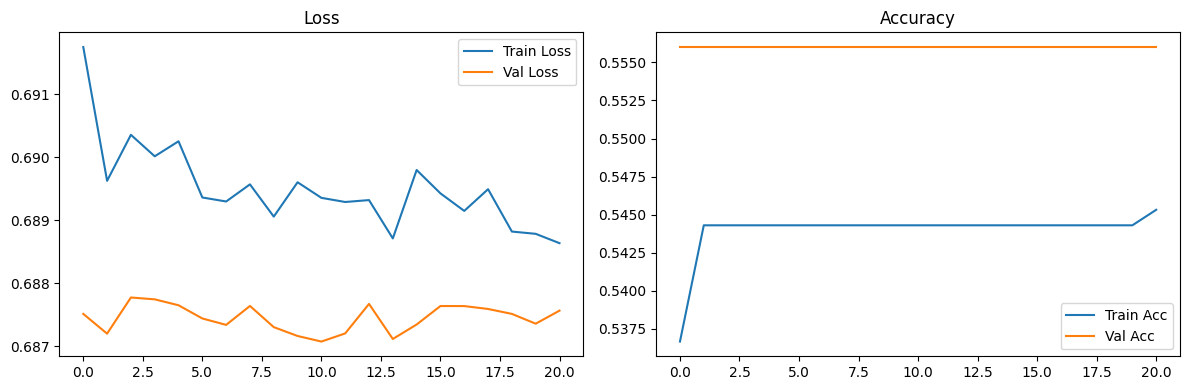

Validation accuracy: 55.60%


In [29]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)[1]
print(f"Validation accuracy: {val_acc:.2%}")